In [2]:
import os

import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import preprocess as pp
from scLEMBAS import io

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [4]:
adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_normalized_counts.h5ad'))

# Infer TF Activity

In [6]:
n_batches = 3
batch_size = int(np.round(adata.n_obs/n_batches))
kwargs = {'args' : {'wsum' : {'times': int(1), # since we don't use the p-vals
                              'batch_size': batch_size},
                       'ulm' : {'batch_size': batch_size}, 
                        'mlm': {'batch_size': batch_size}
                       }, 
         'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['wsum_estimate', 'ulm_estimate', 'mlm_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values



adata = pp.get_tf_activity(adata = adata, 
                           organism = 'human', 
                           grn = 'collectri', 
                           verbose = True,
                           consensus = True, 
                           hvg = True,
                           static = True,
                           use_raw = False, 
                           min_n = 5, 
                           filter_pvals = False, pval_thresh = 0.05, 
                           **kwargs)

Running scores.
Running wsum on mat with 72471 samples and 5000 targets for 516 sources.


100%|█████████████████████████████████████████████| 3/3 [00:01<00:00,  2.72it/s]


Running ulm on mat with 72471 samples and 5000 targets for 516 sources.


100%|█████████████████████████████████████████████| 3/3 [00:02<00:00,  1.43it/s]


Running mlm on mat with 72471 samples and 5000 targets for 516 sources.


100%|█████████████████████████████████████████████| 3/3 [00:20<00:00,  6.67s/it]


Let's see what the data distribution looks like (and if it was transformed as in the original LEMBAS):

''

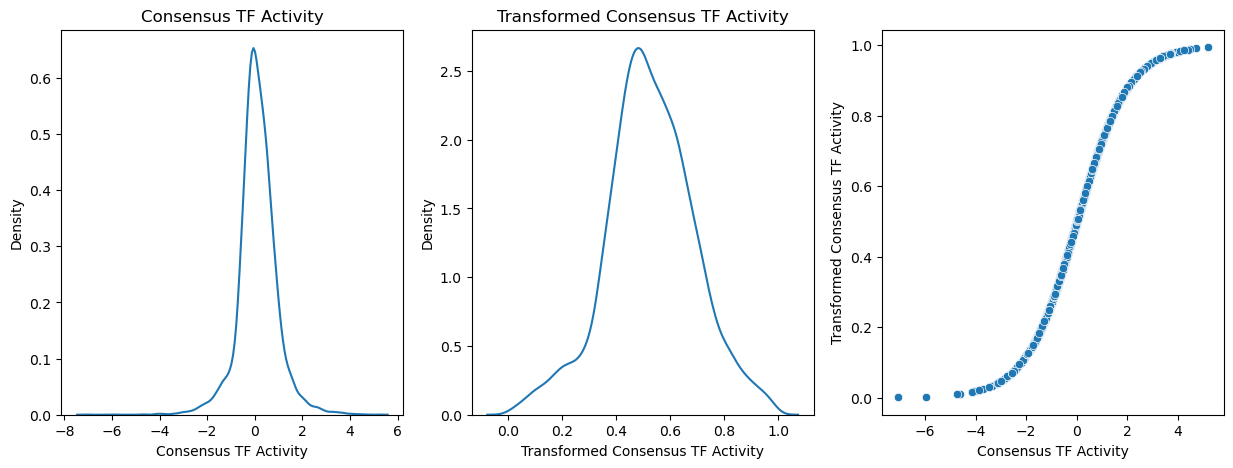

In [7]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

vals = adata.obsm['consensus_estimate'].values.flatten()
vals_transformed = pp.transform_tf_activity(adata.obsm['consensus_estimate']).values.flatten()
scores = pd.DataFrame(data = {'Consensus TF Activity': vals, 
                    'Transformed Consensus TF Activity': vals_transformed})
scores_subset = scores.sample(n=int(1e4), random_state=seed)


sns.kdeplot(scores_subset['Consensus TF Activity'], ax = ax[0])
ax[0].set_title('Consensus TF Activity')

sns.kdeplot(scores_subset['Transformed Consensus TF Activity'], ax = ax[1])
ax[1].set_title('Transformed Consensus TF Activity')

sns.scatterplot(data = scores_subset, x = 'Consensus TF Activity', 
                y = 'Transformed Consensus TF Activity', ax = ax[2])
;

In [8]:
tf_adata = pp.tf_to_adata(adata, estimate_key = 'consensus_estimate')
tf_adata = tf_adata[:, sorted(tf_adata.var_names)].copy() # doesnt change anything

# Latent Space and Quantification

Here, we get the embeddings in PLS and PCA space. We also quantify the extent to which, in these latent spaces, each covariate of interest is represented. We do this because if there is limited perturbation signal relative to other covariates, we cannot expect training of model to capture that signal in the reconstruction loss.

In [8]:
from scLEMBAS import latent_separation as ls

In [7]:
cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'
covariates = [cat_col, pert_col, 'assigned_donor', 'phase']
comparison_metric = 'chance_adjusted_accuracy'

PCA quantification:

In [19]:
tf_adata, _, cv_df_pca_global_round1 = ls.pc_pipeline(
    adata = tf_adata, 
    pert_ids = tf_adata.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata.obs[cat_col].unique().tolist(),
    n_components = None, # automatically determine
    pert_col = pert_col,
    cat_col = cat_col,
    get_hvgs = False, 
    run_umap = True, 
    covariate_associations = covariates, 
    per_component_association = False, 
    global_component_association = True,
    file_prefix = os.path.join(data_path, 'interim', author + '_latent_association_pca'), 
    verbose = True,
    n_cores = n_cores, 
    seed = seed,
    embkwrgs = {
        'cluster_data': True, 
        'n_neighbors': 15,
        'resolution': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
        'cluster_col_name': 'TF_clusters',
        'nmi_label': 'condition', 
        
        'scale': False, # TF activity is z-scored
        'pcakwrgs': {
            'use_highly_variable': False, # TF activity is z-scored
            'zero_center': False # there are no HVGs so this is by default the behavior
        }    
    }
)

In [16]:
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}

tf_adata, _, cv_df_pls_global_round1 = ls.pls_da_pipeline(
    adata = tf_adata, 
    pert_ids = tf_adata.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata.obs[cat_col].unique().tolist(),
    n_components = None,
    control_confounders = None, 
    assess_pls_fit = True,
    pert_col = pert_col,
    cat_col = cat_col,
    separate_by = 'perturbation',
    pls_kwargs = None, 
    component_selection_kwargs = csw,
    assessment_kwargs = assessment_kwargs,
    covariate_associations = covariates,
    per_component_association = False, 
    global_component_association = True,
    run_umap = True,
    file_prefix = os.path.join(data_path, 'interim', author + '_latent_association_pls'),
    verbose = True,
    n_cores = n_cores,
    seed = seed
)
pls_model = tf_adata.uns['pls']['pls_mod']

-----PCA-----
Elbow selection via variance explained identified 14 as the optimal number of PCA components
-----PLS-----
Elbow selection via accuracy identified 12 as the optimal number of PLS components
The model fit has a R2Y of 0.22
The model fit has a Q2Y of 0.22, with p-value 0.010
The model fit has a accuracy of 0.45


''

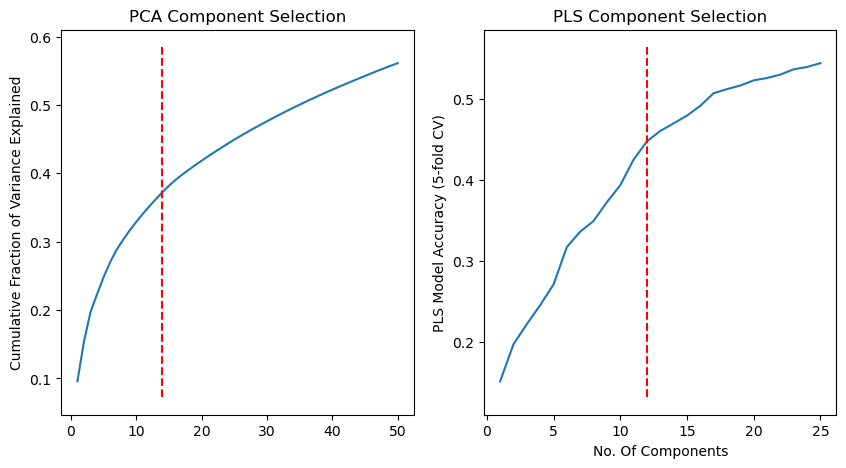

In [35]:
print('-----PCA-----')
n_pca = tf_adata.uns['pca']['pca_rank']
print('Elbow selection via variance explained identified {} as the optimal number of PCA components'.format(n_pca))

print('-----PLS-----')
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model.n_components))
for metric_type, metric_vals in pls_model.assessment_metrics.items():
    if metric_type != 'R2X':
        if metric_vals['pval'] is None:
            print('The model fit has a {} of {:.2f}'.format(
                metric_type, metric_vals['value']
            ))
        else:
            print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
                metric_type, metric_vals['value'], metric_vals['pval']
            ))
            
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

i = 0
cumulative_variance_ratio = np.cumsum(tf_adata.uns['pca']['variance_ratio']) #adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(cumulative_variance_ratio))) + 1
sns.lineplot(x = pcs, y = cumulative_variance_ratio, ax = ax[i])

ymin, ymax = ax[i].get_ylim()
ax[i].vlines(x = n_pca, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
             color = 'red', linestyle = '--')
ax[i].set_title('PCA Component Selection')
ax[i].set_ylabel('Cumulative Fraction of Variance Explained')



i = 1
sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[i])
ymin, ymax = ax[i].get_ylim()
ax[i].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax[i].set_xlabel('No. Of Components')
ax[i].set_ylabel('PLS Model Accuracy (5-fold CV)')
# ax[i].legend()
ax[i].set_title('PLS Component Selection')
;

''

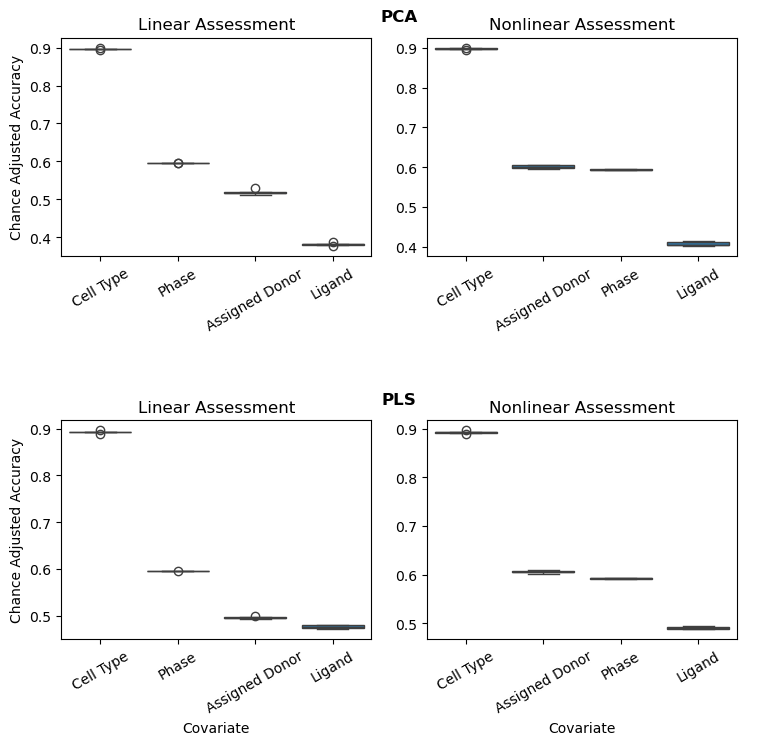

In [72]:
cv_globals = {'PCA': cv_df_pca_global_round1, 
             'PLS': cv_df_pls_global_round1}
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (8, 8))



for i, (ls_type, cv_global) in enumerate(cv_globals.items()):
    row_ax = fig.add_subplot(2, 1, i + 1, frame_on=False)
    row_ax.set_title(ls_type, fontsize=12, fontweight='bold', pad=12)
    row_ax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    row_ax.grid(False)
    for j, model_type in enumerate(cv_global.model_type.unique()):
        viz_df = cv_global[cv_global.model_type == model_type]
        viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
        viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
        viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
        x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
        viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
        viz_df.covariate = viz_df.covariate.apply(lambda x: ' '.join([x_.capitalize() for x_ in x[:-1].split('_')]))

        sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i,j])
        for label in ax[i,j].get_xticklabels():
            label.set_rotation(30)
                    
        
        ax[i,j].set_xlabel('Covariate') if i == 1 else ax[i,j].set_xlabel('')
        ax[i,j].set_ylabel('Chance Adjusted Accuracy') if j == 0 else ax[i,j].set_ylabel('')
        ax[i,j].set_title(model_type.capitalize() + ' Assessment') #if i == 0 else ax[i,j].set_title('')
    
fig.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_ls_quantification.png'), 
            dpi=300, bbox_inches="tight")

;

We can see from the PCA space that ligand has the weakest relative signal in both linear and non-linear assessments; it is weaker than cell type, biological signals that are not of interest (cell cycle phase), and batch effects (donor). Using PLS rather than PCA doesn't change this relative ordering. This means it will be quite difficult for the reconstruction loss to capture that signal. Let's look at this visually as well:

''

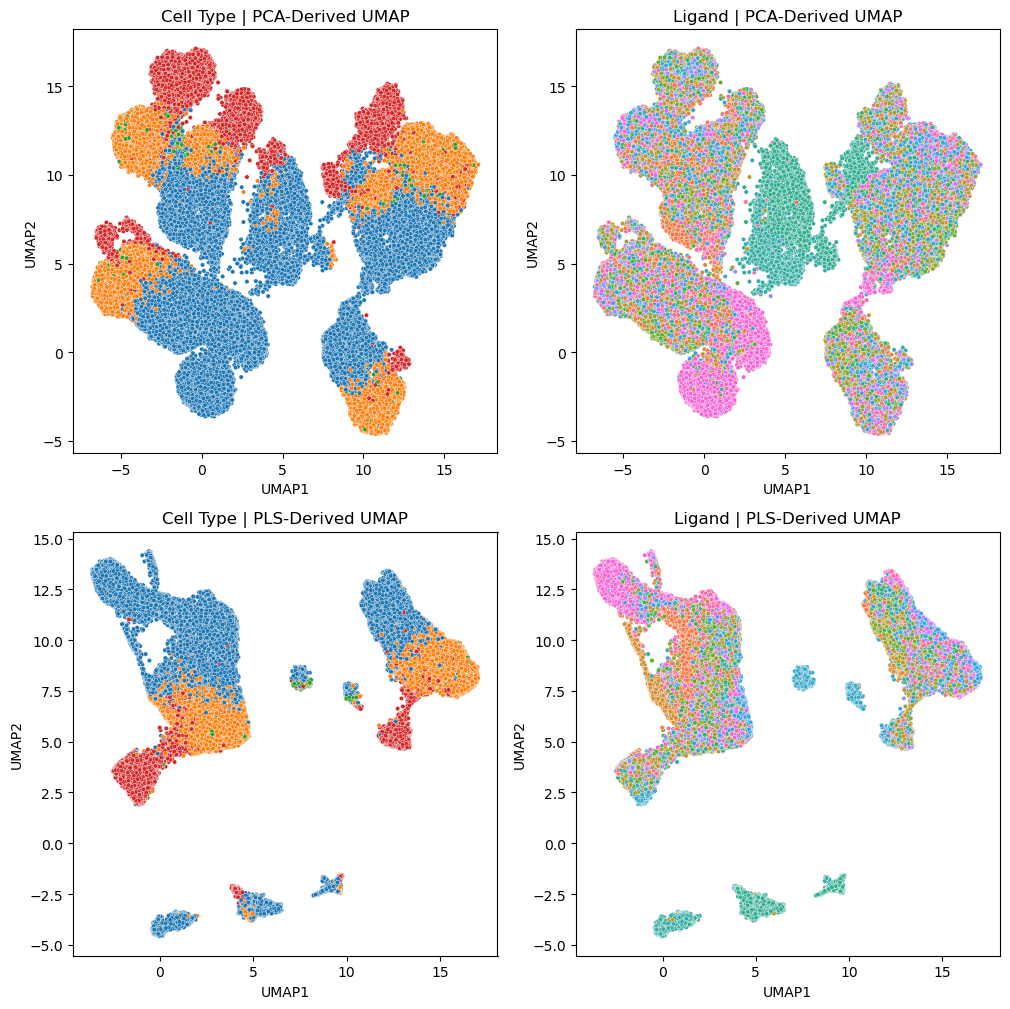

In [99]:
ncols, nrows = 2,2
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'umap': 'PCA-Derived UMAP', 
         'umap_pls': 'PLS-Derived UMAP'}

for i, latent_label in enumerate(['umap', 'umap_pls']):
    viz_df = pd.DataFrame(tf_adata.obsm['X_' + latent_label])
    _label_name = 'UMAP'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10)
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None:
            ax[i,j].legend_.remove()
            
        ax[i,j].set_title('{} | {}'.format(
            ' '.join([c.capitalize() for c in covariate.split('_')]), 
            ll_map[latent_label]))

fig.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_umap_visualization.png'), 
            dpi=300, bbox_inches="tight")
;

Only showing a 30% subset:

''

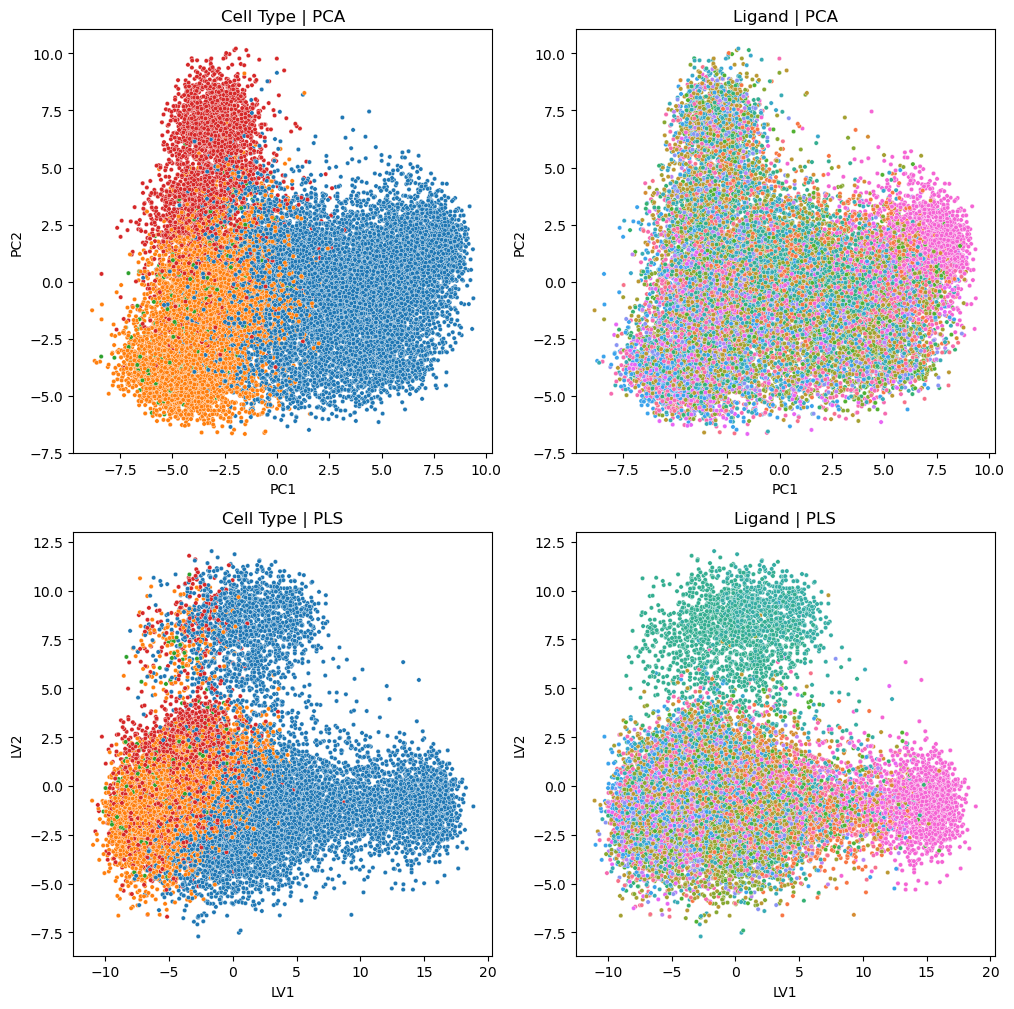

In [9]:
ncols, nrows = 2,2
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows))
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'pca': 'PCA', 
         'pls': 'PLS-Derived UMAP'}

for i, latent_label in enumerate(['pca', 'pls']):
    viz_df = pd.DataFrame(tf_adata.obsm['X_' + latent_label])
    _label_name = 'PC' if latent_label == 'pca' else 'LV'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=0.3, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10)
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None:
            ax[i,j].legend_.remove()
            
        ax[i,j].set_title('{} | {}'.format(
            ' '.join([c.capitalize() for c in covariate.split('_')]), 
            latent_label.upper()))

fig.tight_layout()
fig.savefig(os.path.join(data_path, 'figures', author + '_TF_pca_pls_visualization.png'), 
            dpi=300, bbox_inches="tight")
;

The embedding visualizations reflect the quantification, indicating that cell type has much more distinct programs than perturbation. 

Formatting

In [117]:
io.write_tfad(tf_adata, os.path.join(data_path, 'interim', author + '_tf_activity_all.h5ad'))